ML:
1. Wasserstein: 3 pairs: (b_0(f),b_0(g)) (b_0^1(f),b_0^1(g)) (b_1(f)U b_2(g),b_1(g) Ub_2(f))
2. Persistence Image: Gassusian +b_1 - b_2

In [1]:
import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
import numpy as np

Let's see the performance of DTree and Dendrogram on random graphs

In [2]:
import time
t_den = 0
t_dt = 0
wrongs = []
for i in range(0,10):
    np.random.seed(i)
    n_nodes = 200
    n_edges = 1000
    nodes = np.arange(1, n_nodes+1, dtype=int)
    edges = np.random.randint(1, n_nodes+1, size=(n_edges, 2))
    node_features = np.zeros(shape=(n_nodes, 2), dtype = np.double)

    # edge_features = np.random.randint(5, 10, size=(n_edges, 2)).astype(np.double)
    edge_features = np.random.uniform(low=5.0, high=10.0, size=(n_edges, 2)).astype(np.double)
    edge_features = np.round(edge_features, 2)
    # edge_str_labels = [f"({row[0]},{row[1]})" for row in edge_features]
    
    # Create the Graph object
    mph_g = abmph.Graph(nodes, node_features, edges, edge_features)
    time_1 = time.time()
    res_dt = abmph.compute_MPH0_DTree(mph_g) 
    time_2 = time.time()
    res_den = abmph.compute_MPH0_Dengrogram(mph_g)
    time_3 = time.time()
    t_dt += (time_2-time_1)
    t_den += (time_3-time_2)
    
    if res_dt != res_den:
        wrongs.append(i)
        print(i)
        print(abmph.compute_MPH0_DTree(mph_g))
        print(abmph.compute_MPH0_Dengrogram(mph_g))
        break

In [3]:
wrongs, t_dt, t_den

([], 1.2076523303985596, 5.7387330532073975)

They produce the same results, and DTree is much faster!

You may want to see a graph explicly. Let's generate one.

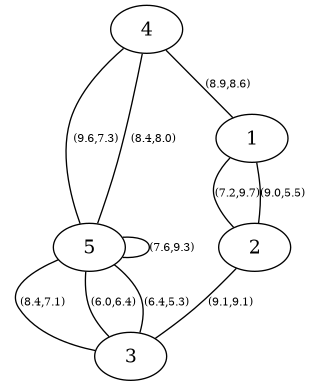

In [4]:
import pygraphviz as pgv
import matplotlib.pyplot as plt
from PIL import Image
np.random.seed(1)
n_nodes = 5
n_edges = 10
nodes = np.arange(1, n_nodes+1, dtype=int)
edges = np.random.randint(1, n_nodes+1, size=(n_edges, 2))
node_features = np.zeros(shape=(n_nodes, 2), dtype = np.double)
# edge_features = np.random.randint(5, 10, size=(n_edges, 2)).astype(np.double)
edge_features = np.random.uniform(low=5.0, high=10.0, size=(n_edges, 2)).astype(np.double)
edge_features = np.round(edge_features, 1)
edge_str_labels = [f"({row[0]},{row[1]})" for row in edge_features]

# Create a new AGraph (directed graph)
G = pgv.AGraph(strict=False, directed=False)

for i, row in enumerate(edges):
    G.add_edge(row[0], row[1], label=edge_str_labels[i])
    
# Draw the graph to a file
G.layout(prog='dot',args="-Efontsize=8")  # Use the 'dot' layout engine
G.draw('graph.png')

# Display the graph using PIL
img = Image.open('graph.png')
img.show()

Their filtration values on the plane:

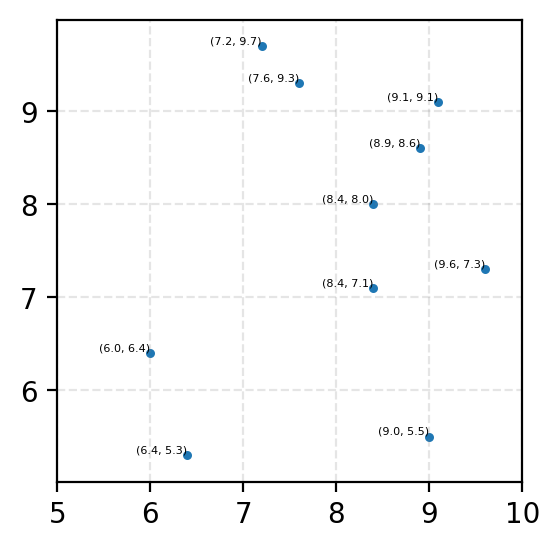

In [5]:
plt.figure(figsize=(3, 3), dpi=200)

plt.scatter(edge_features[:,0], edge_features[:,1], s = 5)
plt.axis('equal')
plt.xlim(5, 10)
plt.ylim(5, 10)
# Annotate each point with its (x, y) coordinates
for i in range(len(edge_features)):
    x, y = edge_features[i, 0], edge_features[i, 1]
    plt.text(x, y, f'({x}, {y})', fontsize=4, ha='right', va='bottom')

plt.grid(True, linestyle='--', color='gray', alpha=0.2)

plt.show()

## dgl graph to mph graph
Now let's see a complex graph from the real world. We will perform the graph classfication task later. 

In [6]:
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl.data
import numpy as np
dataset = dgl.data.TUDataset(name = 'Cuneiform', raw_dir='../data')
print('Number of categories:', dataset.num_classes)
print('Number of graphs:', len(dataset))
g, label = dataset[0] # pick the first graph

/root/miniconda3/envs/dl/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()
/root/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of categories: 30
Number of graphs: 267


In [7]:
# generate the graph filtration values and save them
# note that filtration value should be positive 
# you should make sure that it is indeed a valid filtration!
# i.e. vertices of each edge appear before the edge.  
from sklearn.preprocessing import StandardScaler
e_0s, e_1s, e_ids = g.edges(form='all',  order='srcdst')
node_labels = g.nodes().numpy()
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.vstack((e_0s.numpy(), e_1s.numpy())).T
# Create a StandardScaler object
scaler = StandardScaler()
edge_features = scaler.fit_transform(g.edata['node_labels'].numpy())

np.save("../data/node_labels.npy", node_labels)
np.save("../data/node_features.npy", node_features)
np.save("../data/edges_input.npy", edges_input)
np.save("../data/edge_features.npy", edge_features)

In [8]:
# construct graph
def standardize_array(arr):
    # Step 1: Normalize to [0, 1]
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    arr_normalized = (arr - arr_min) / (arr_max - arr_min)

    # Step 2: Adjust standard deviation to 1
    arr_std = np.std(arr_normalized)
    arr_standardized = arr_normalized / arr_std
    return arr_standardized


node_labels = np.load("../data/node_labels.npy")
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.load("../data/edges_input.npy")
edge_features = standardize_array(np.load("../data/edge_features.npy"))

g2 = abmph.Graph(node_labels, node_features, edges_input, edge_features)

In [9]:
res_den = abmph.compute_MPH0_Dengrogram(g2)
res_dt = abmph.compute_MPH0_DTree(g2)
res_den == res_dt

True